## Identifying Pulsar stars
- Dataset obtained from [Kaggle](https://www.kaggle.com/datasets/colearninglounge/predicting-pulsar-starintermediate/data)
- Training SVM to predict:
    - 0 = Not a pulsar star
    - 1 = Pulsar star
- Model used: SVM & RF

DataFrame shape:  (12528, 9)
Number of duplicate rows: 0
________________________________________

Null values (train):
 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile       1735
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve          1178
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     625
target_class                                        0
dtype: int64 
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12528 entries, 0 to 12527
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                12528 non-null  float64
 1 

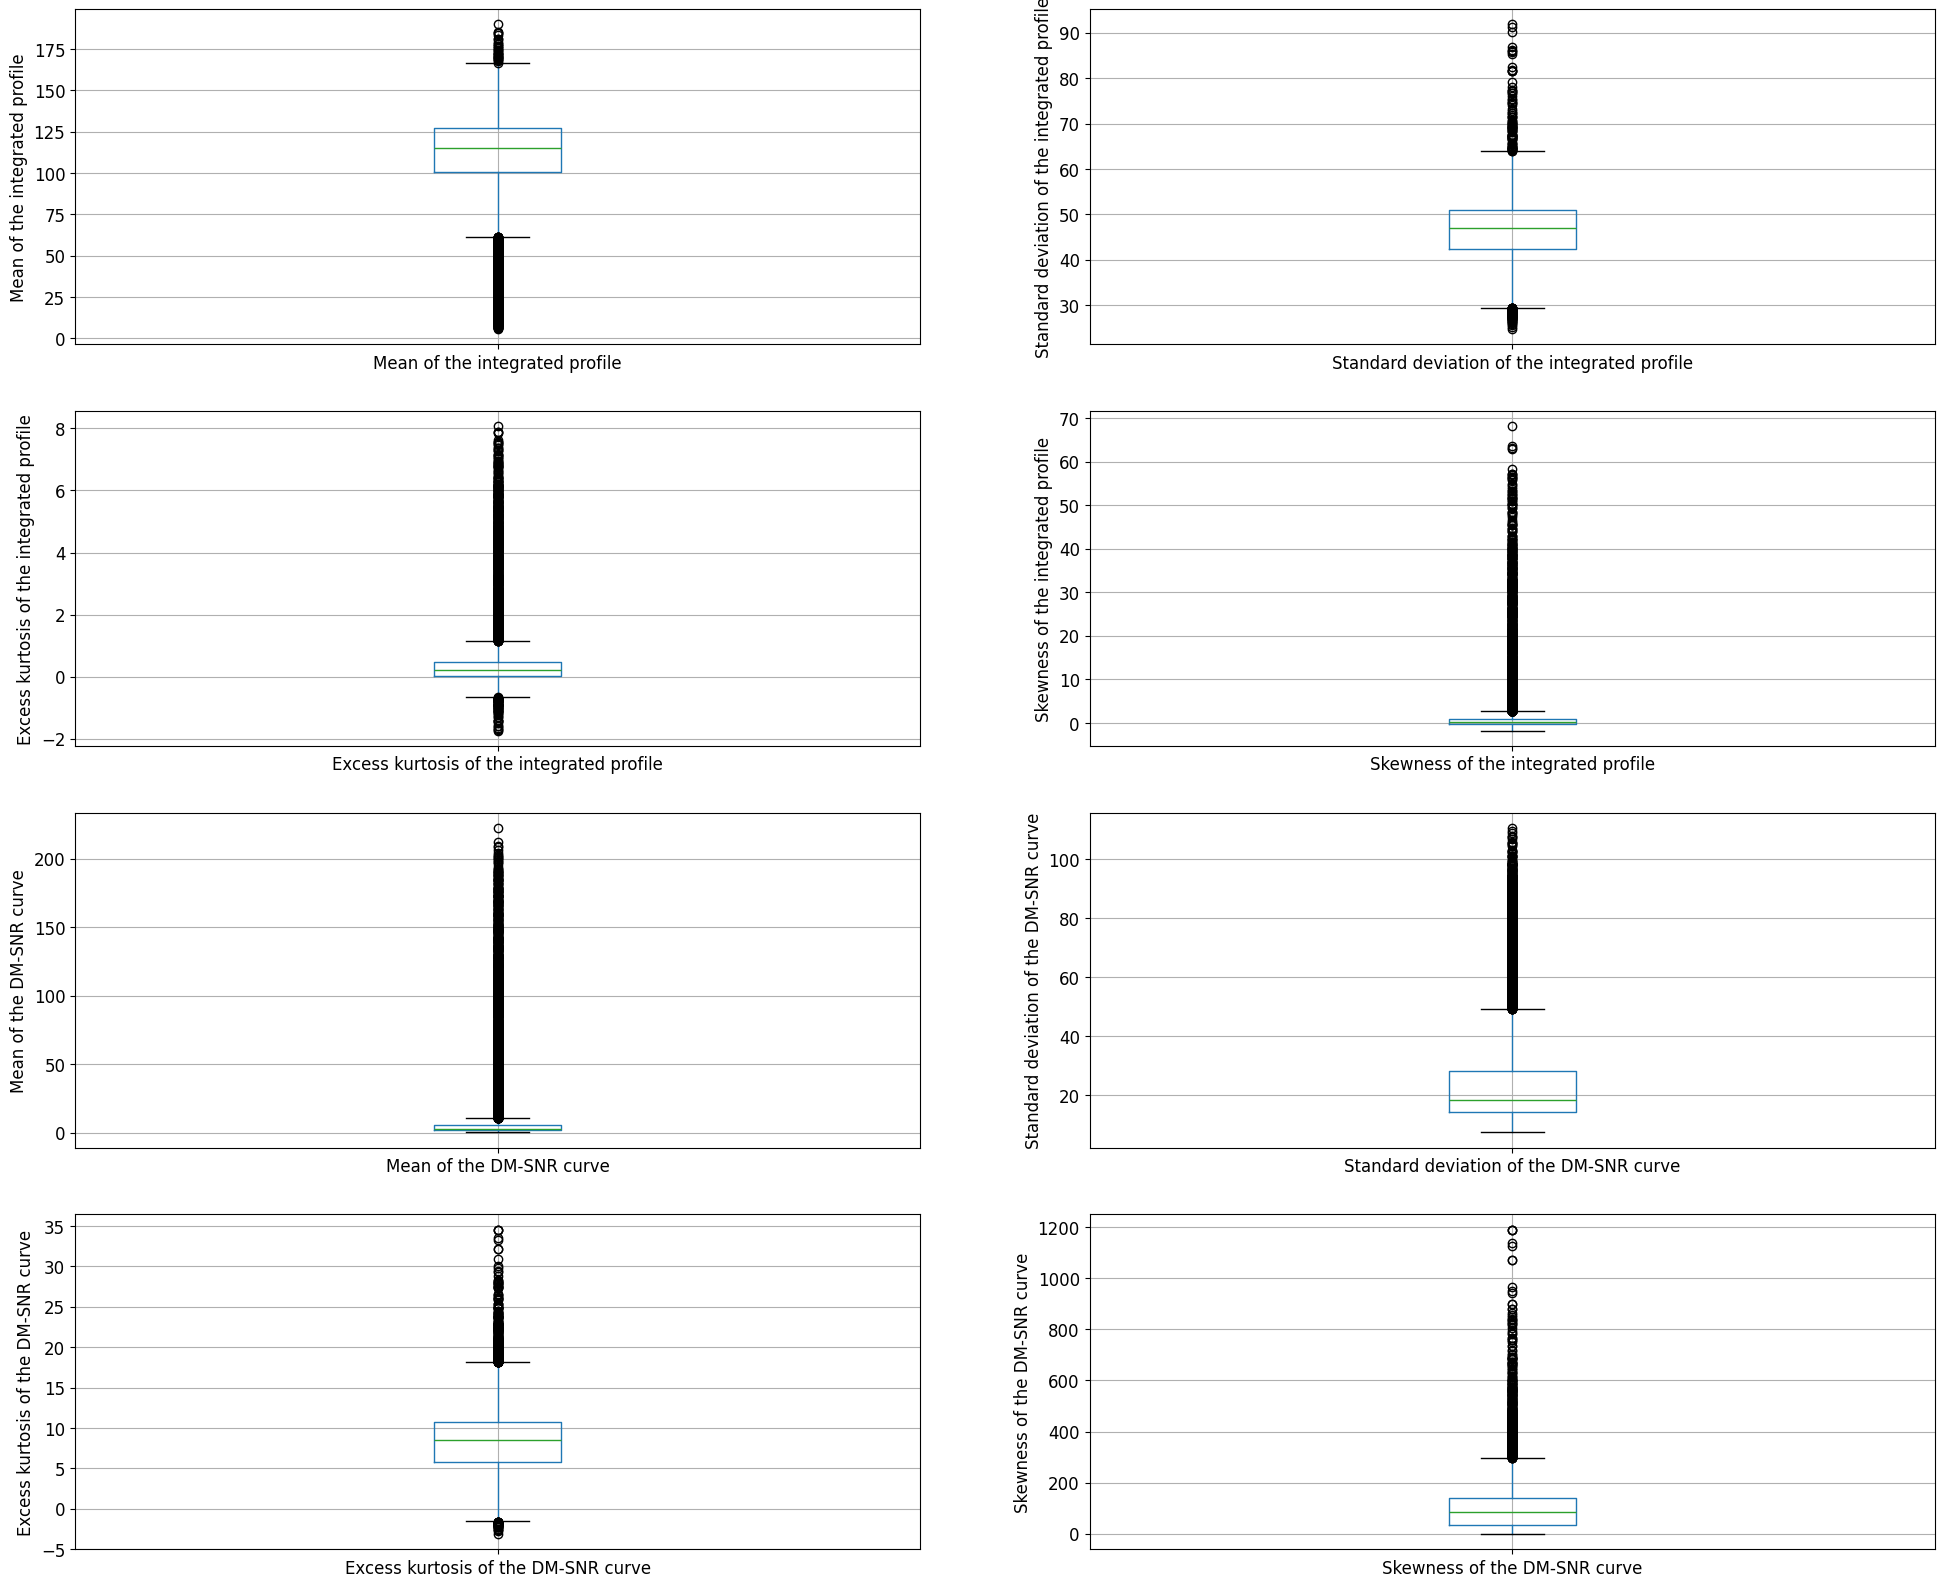

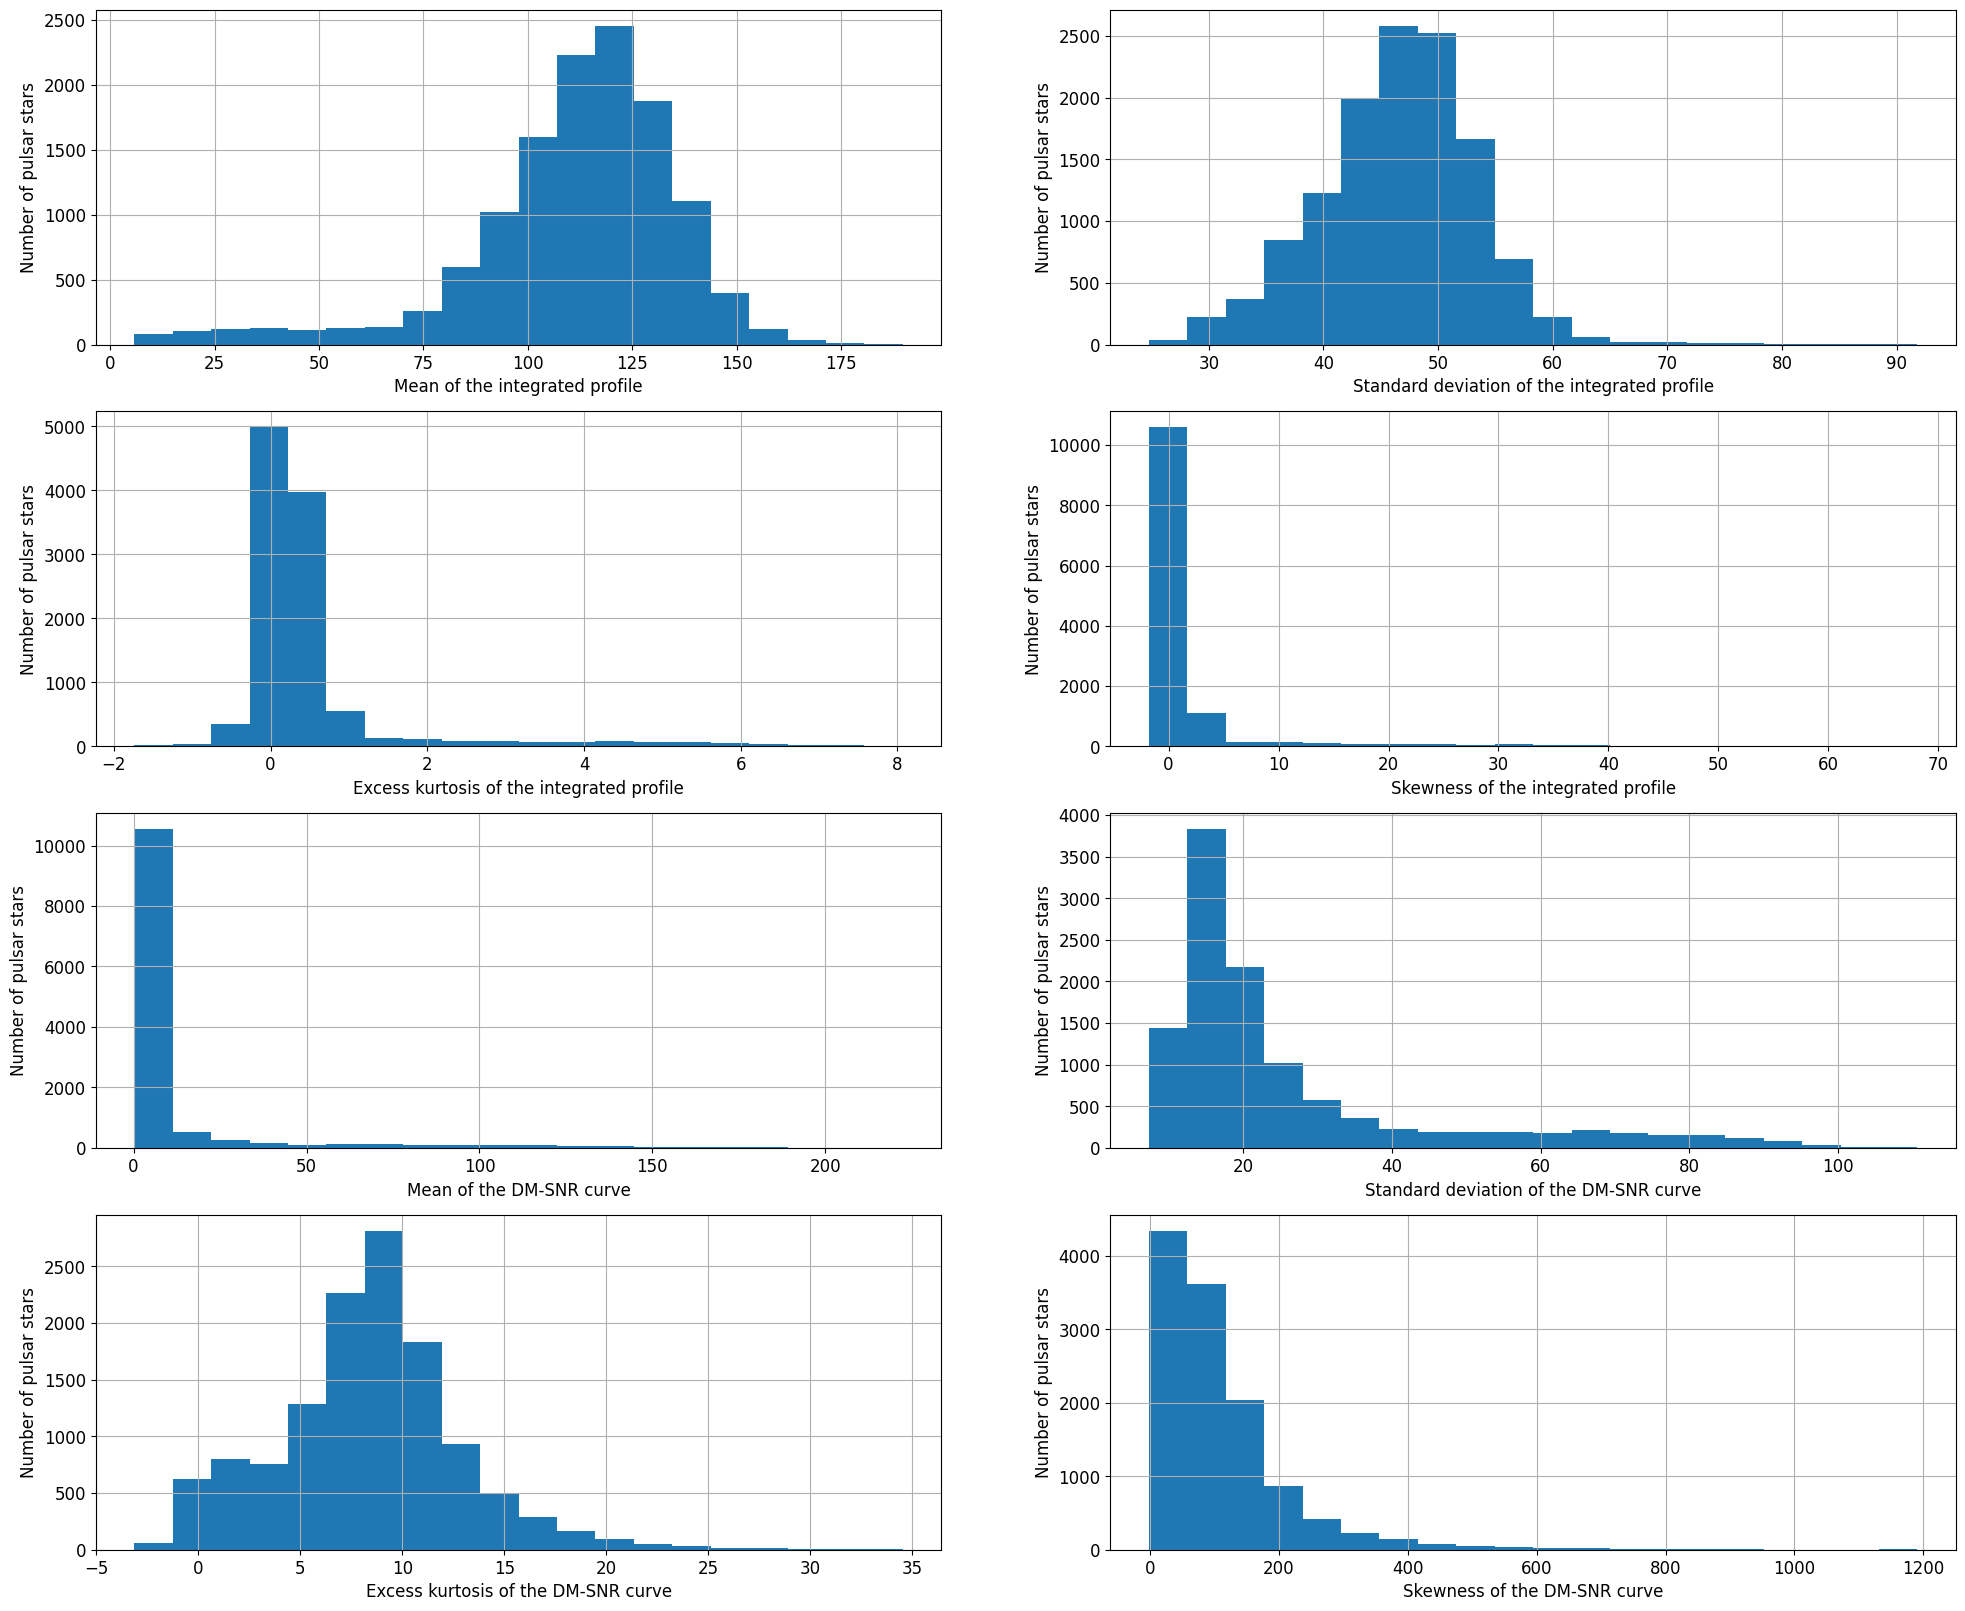

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 0: Data Exploration
df = pd.read_csv("pulsar_data.csv")
print("DataFrame shape: ", df.shape) # (rows, columns)

# Check for any duplicate rows
print('Number of duplicate rows: ' + str(df.duplicated().sum()))
print('_' * 40)

# Check for any missing values
print(f"\nNull values (train):\n{df.isnull().sum()} ")
print('_' * 40)

print(f"{df.info()}") 
print('_' * 40)

# remove any whitespace from column names
df.columns = df.columns.str.strip()

# Check for any Negative values
numerical_feature_list = df.select_dtypes(include="number").columns
negatives = (df[numerical_feature_list] < 0).sum().loc[lambda x: x > 0]
for col, count in negatives.items():
    print(f"{col} has {count} negative values.")
print('_' * 40)

# Check for any outliers (BOX PLOT GRAPH)
plt.figure(figsize=(24,20))
# temporary drop the target value to see features outliers only
temp = df.drop(columns='target_class') 
a = 1
for i in temp.columns:
    plt.subplot(4, 2, a)
    fig = temp.boxplot(column=i)
    fig.set_ylabel(i)
    a+=1

# Check for distribution (Normal or skewed) (HISTOGRAPH)
plt.figure(figsize=(24,20))
a = 1
for i in temp.columns:
    plt.subplot(4, 2, a)
    fig = temp[i].hist(bins=20)
    fig.set_xlabel(i)
    fig.set_ylabel('Number of pulsar stars')
    a+=1

print(df[["target_class"]].value_counts(normalize=True) * 100)

- Observations: 
    - There's 4 column variables with negative values.
    - All column variables have outliers based on graph. 
    - There are 3 columns that contains null values. 
    - All column variables are skewed. 
    - The target class distribution is highly unbalanced (91% is class 0, while 9% is class 1).

In [2]:
# Step 2: Spliting data and Handling features
from sklearn.model_selection import train_test_split

X = df.drop(['target_class'], axis=1)
y = df['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Handling missing value and standardize features
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Median imputation (fit only on training data).  median = numerical. Mode = categorical. 
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
# Step 3: Baseline hyperparameter model
# import SVC classifier
from sklearn.svm import SVC

# import metrics to compute accuracy
from sklearn.metrics import accuracy_score

# instantiate classifier with default hyperparameters
svc=SVC() 

# fit classifier to training set
svc.fit(X_train,y_train)

# make predictions on test set
y_pred=svc.predict(X_test)

# compute and print accuracy score
print('SVC accuracy score (default hyperparameters): {0:0.4f}'. format(accuracy_score(y_test, y_pred)))


SVC accuracy score (default hyperparameters): 0.9792


In [4]:
# See svc parameters:
svc.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

- The main parameters:
    - `C`: It regularize parameter. 
        - Higher C = Classify more training point, but too much can lead to overfitting.
    - `kernel`: It transform data.
        - linear: For data that is already simple and linearly separable.
        - rbf (Radial Basis Function): The gold-standard default. Great for organic, circular, or complex non-linear boundary shapes.
        - poly: Creates polynomial boundaries for relationships that are curved/quadratic.
    - `gamma`: Controls how far the influence of each training example reaches.
        - Low gamma: Even faraway training points still influence the decision. This produces a smoother decision boundary and may underfit.
        - High gamma: Only nearby training points influence the decision. This produces a more wiggly decision boundary that can fit individual data points closely and may overfit.

In [32]:
# Step 3: Finding best hyperparameter model using GridSearch
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svc_model = SVC()

# 2. Define the hyperparameter grid you want to search
param_grid = [ {'C':[1, 10, 100, 1000], 'kernel':['linear']},
               {'C':[1, 10, 100, 1000], 'kernel':['rbf'], 'gamma':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]},
               {'C':[1, 10, 100, 1000], 'kernel':['poly'], 'degree': [2,3,4] ,'gamma':[0.01,0.02,0.03,0.04,0.05]} 
              ]
# Initialize GridSearchCV (using 5-fold cross-validation)
# 5 cv = Train the model 5 separate times for each single parameter combination. (4 for training, 1 for validation)
grid_search = GridSearchCV(
    estimator=svc_model, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=3,
)

# Fit the tuning process directly on your already-scaled training data
grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters Found: {'C': 10, 'gamma': 0.2, 'kernel': 'rbf'}
Best Score: 0.877121682983572


Now let's train Random_forest classifier model.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(random_state=0)

rf_param_grid = {
    "n_estimators": [50, 100, 200],  # Number of trees in the forest
    "max_depth": [None, 10, 20],  # How deep the trees can grow
    "criterion": ["gini", "entropy"],  # How to measure the quality of a split
}

# Pass the RF model and the RF parameters into the GridSearch
rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1, 
    verbose=3, # optional: Prints information during training
)

# 4. Fit the RF grid search
rf_grid_search.fit(X_train, y_train)

print("Best Parameters Found:", rf_grid_search.best_params_)
print("Best Score:", rf_grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters Found: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 50}
Best Score: 0.8813716088504087


- Based on the 2 models (SVC & randomForest) trained, the best model would be Random Forest as it got higher cross-validation F1-score. 

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
 
print("SVC model:\n")
# `grid_search` automatically points to the best model configuration)
y_pred_svc = grid_search.predict(X_test)

# Final Test Accuracy
final_acc = accuracy_score(y_test, y_pred_svc)
print(f"Test Accuracy Score: {final_acc:0.4f}\n")

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))
print("-" * 55)

# Classification Report (F1-Score, Precision, and Recall)
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))

SVC model:

Test Accuracy Score: 0.9800

Confusion Matrix:
[[2275   10]
 [  40  181]]
-------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2285
         1.0       0.95      0.82      0.88       221

    accuracy                           0.98      2506
   macro avg       0.97      0.91      0.93      2506
weighted avg       0.98      0.98      0.98      2506



In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
 
print("RF model:\n")
# `grid_search` automatically points to the best model configuration)
y_pred_rf = rf_grid_search.predict(X_test)

# Final Test Accuracy
final_acc = accuracy_score(y_test, y_pred_rf)
print(f"Test Accuracy Score: {final_acc:0.4f}\n")

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("-" * 55)

# Classification Report (F1-Score, Precision, and Recall)
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

RF model:

Test Accuracy Score: 0.9796

Confusion Matrix:
[[2274   11]
 [  40  181]]
-------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2285
         1.0       0.94      0.82      0.88       221

    accuracy                           0.98      2506
   macro avg       0.96      0.91      0.93      2506
weighted avg       0.98      0.98      0.98      2506



- class 0 (total normal stars): 2285
- class 1 (total pular stars): 221 
- matrix `accuracy = (TP + TN) / float(TP + TN + FP + FN)`

Confusion matrix shows:

| **Actual \ Predicted** |               **Normal (0)** |              **Pulsar (1)** |
| ---------------------- | ---------------------------: | --------------------------: |
| **Normal (0)**         | **2274** (True Negative, TN) | **11** (False Positive, FP) |
| **Pulsar (1)**         |  **40** (False Negative, FN) | **181** (True Positive, TP) |

- It correctly idenitifed Normal stars 2274. But it misidentified 11 Normal stars as Pulsars.
- It correctly identified Pulsar stars 181. But it misidentified 40 Pulsar stars as Normal.


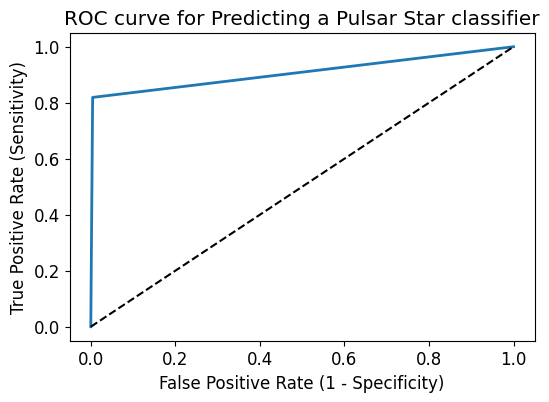

ROC AUC : 0.9073


In [34]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_svc)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Predicting a Pulsar Star classifier')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

# Receiver Operating Characteristic - Area Under Curve
print('ROC AUC : {:.4f}'.format(roc_auc_score(y_test, y_pred_svc)))

## In conculsion
- Even though Random Forest has higher cross-validation F1-score than SVC, It misclassified 2 extra normal stars as pulsars (11 False Positives vs 9) during the test run. 
- Thus, SVC has higher final test accuracy than RF as it can better correctly identified pular stars from normal stars.